## Get the data

In [ ]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip our data
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2024-11-27 16:24:58--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 209.85.200.207, 74.125.132.207, 74.125.201.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|209.85.200.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   150MB/s    in 3.3s    

2024-11-27 16:25:02 (150 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
import os

for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.

In [ ]:
# Setup the train and test directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [ ]:
# Let's get the class names
import pathlib
import numpy as np

data_dir = pathlib.Path(train_dir)

class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))

print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


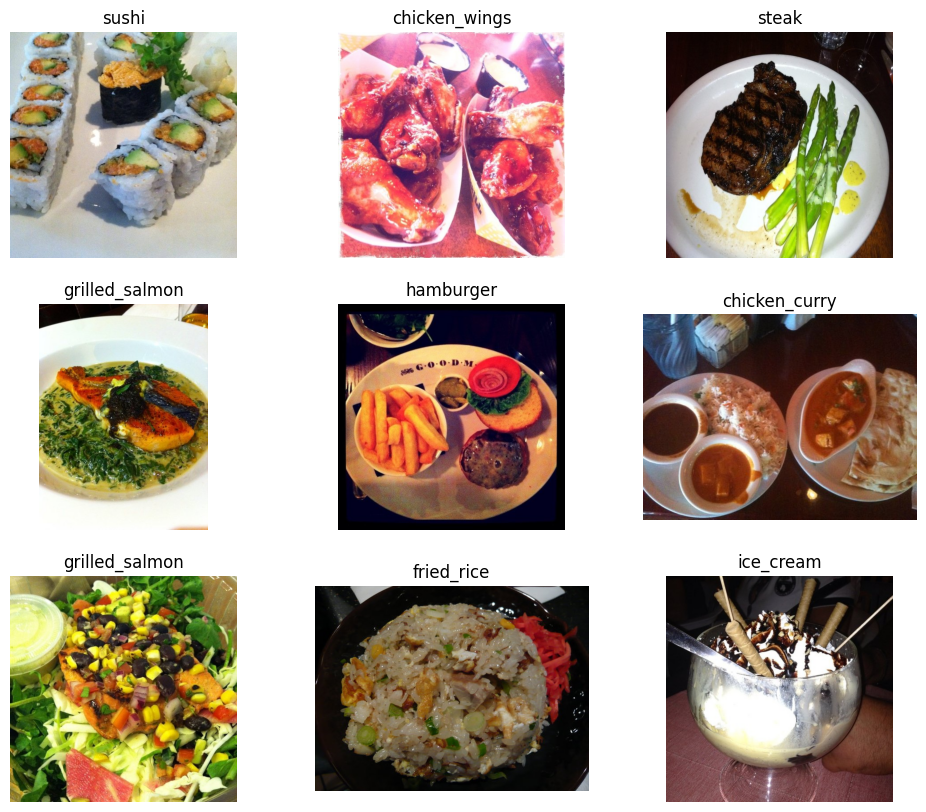

In [ ]:
# Visualize, Visualize, Visualize
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(12, 10))

def visualize_food_img(category):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        if (category == "all"):
            random_class_name = random.choice(class_names)
        else:
            random_class_name = category
        all_imgs = os.listdir(f"{train_dir}{random_class_name}")
        sample_img = random.sample(all_imgs, 1)[0]

        img = mpimg.imread(f"{train_dir}{random_class_name}/{sample_img}")
        plt.imshow(img)
        plt.axis("off")
        plt.title(random_class_name)

visualize_food_img("all")

array([[[255, 254, 252],
        [255, 254, 252],
        [255, 254, 252],
        ...,
        [ 69,  20,   3],
        [ 78,  25,   7],
        [ 78,  25,   7]],

       [[255, 254, 252],
        [255, 254, 252],
        [255, 254, 252],
        ...,
        [ 73,  22,   5],
        [ 81,  28,  10],
        [ 82,  29,  11]],

       [[255, 254, 252],
        [255, 254, 252],
        [255, 254, 252],
        ...,
        [ 72,  21,   4],
        [ 80,  27,   9],
        [ 82,  29,  11]],

       ...,

       [[212, 166, 117],
        [212, 166, 117],
        [211, 164, 118],
        ...,
        [ 73,  35,  14],
        [ 74,  36,  17],
        [ 76,  38,  19]],

       [[212, 166, 117],
        [212, 166, 117],
        [210, 163, 117],
        ...,
        [ 78,  40,  19],
        [ 79,  41,  22],
        [ 78,  40,  21]],

       [[216, 170, 121],
        [215, 169, 120],
        [213, 166, 120],
        ...,
        [ 84,  46,  25],
        [ 84,  46,  27],
        [ 83,  45,  26]]], dtype=uint8)
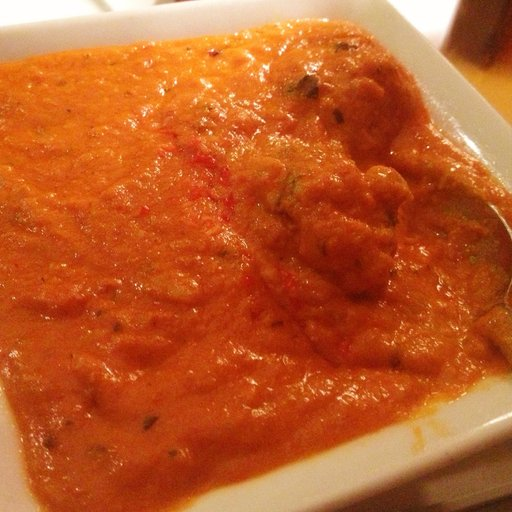

In [ ]:
all_imgs = os.listdir(f"{train_dir}chicken_curry")
sample_img = train_dir + "chicken_curry/" + random.sample(all_imgs, 1)[0]
img_array = mpimg.imread(sample_img)
img_array

In [ ]:
print(img_array)

[[[255 254 252]
  [255 254 252]
  [255 254 252]
  ...
  [ 69  20   3]
  [ 78  25   7]
  [ 78  25   7]]

 [[255 254 252]
  [255 254 252]
  [255 254 252]
  ...
  [ 73  22   5]
  [ 81  28  10]
  [ 82  29  11]]

 [[255 254 252]
  [255 254 252]
  [255 254 252]
  ...
  [ 72  21   4]
  [ 80  27   9]
  [ 82  29  11]]

 ...

 [[212 166 117]
  [212 166 117]
  [211 164 118]
  ...
  [ 73  35  14]
  [ 74  36  17]
  [ 76  38  19]]

 [[212 166 117]
  [212 166 117]
  [210 163 117]
  ...
  [ 78  40  19]
  [ 79  41  22]
  [ 78  40  21]]

 [[216 170 121]
  [215 169 120]
  [213 166 120]
  ...
  [ 84  46  25]
  [ 84  46  27]
  [ 83  45  26]]]


In [ ]:
type(img_array)

numpy.ndarray

In [ ]:
img_array.shape

(512, 512, 3)

In [ ]:
img_array.ndim

3

In [ ]:
img_array.min(), img_array.max()

(0, 255)

In [ ]:
img_array.size

786432

## Data Preprocessing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale
train_datagen = ImageDataGenerator(rescale=1/255.,
                                   rotation_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="categorical")

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode="categorical")

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [ ]:
train_data

In [ ]:
type(train_data)

keras.src.legacy.preprocessing.image.DirectoryIterator

In [ ]:
sample_batch = next(iter(train_data))

In [ ]:
sample_batch

(array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          ...,
          [1.17606868e-03, 1.17606868e-03, 1.17606868e-03],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
 
         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          ...,
          [1.17377052e-03, 1.17377052e-03, 1.17377052e-03],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
 
         [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          ...,
          [1.17147237e-03, 1.17147237e-03, 1.1714

In [ ]:
type(sample_batch)

tuple

In [ ]:
batch_imgs = sample_batch[0]

In [ ]:
batch_imgs

array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.17606868e-03, 1.17606868e-03, 1.17606868e-03],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.17377052e-03, 1.17377052e-03, 1.17377052e-03],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.17147237e-03, 1.17147237e-03, 1.17147237e-03],
         [

In [ ]:
batch_imgs.shape

(32, 224, 224, 3)

In [ ]:
batch_labels = sample_batch[1]

In [ ]:
batch_labels

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 

In [ ]:
type(batch_labels)

numpy.ndarray

In [ ]:
batch_labels.shape

(32, 10)

In [ ]:
batch_labels.dtype

dtype('float32')

In [ ]:
batch_labels.ndim

2

In [ ]:
batch_labels.size

320

## Creating the model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Activation

# Create our model (very similar to previous models but actually the same as CNN explainer website)
computer_vision_cnn_model = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    Conv2D(10, 3),
    Activation(activation="relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax"), # changed to have 10 output neurons and use the softmax activation function
])

# Compile the model
computer_vision_cnn_model.compile(loss="categorical_crossentropy",
                                  optimizer=tf.keras.optimizers.Adam(),
                                  metrics=["accuracy"])

In [ ]:
computer_vision_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 222, 222, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 220, 220, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 110, 110, 10)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 108, 108, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 106, 106, 10)        │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 53, 53, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28090)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │         280,910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
history = computer_vision_cnn_model.fit(train_data, # Augmented Data
                                            epochs=5,
                                            validation_data=test_data,
                                            validation_batch_size=len(test_data))

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


235/235 ━━━━━━━━━━━━━━━━━━━━ 100s 386ms/step - accuracy: 0.1370 - loss: 2.2920 - val_accuracy: 0.2720 - val_loss: 2.0339
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 373ms/step - accuracy: 0.2510 - loss: 2.0825 - val_accuracy: 0.2820 - val_loss: 2.0623
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 374ms/step - accuracy: 0.2960 - loss: 1.9853 - val_accuracy: 0.3496 - val_loss: 1.8798
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 373ms/step - accuracy: 0.3165 - loss: 1.9511 - val_accuracy: 0.3780 - val_loss: 1.8464
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 373ms/step - accuracy: 0.3401 - loss: 1.9101 - val_accuracy: 0.3752 - val_loss: 1.8153


In [ ]:
import pandas as pd

In [ ]:
model_metrics = pd.DataFrame(history.history)
model_metrics

,accuracy,loss,val_accuracy,val_loss
0,0.164800,2.228103,0.2720,2.033876
1,0.274667,2.042309,0.2820,2.062345
2,0.304400,1.979513,0.3496,1.879768
3,0.327467,1.932876,0.3780,1.846406
4,0.347067,1.902548,0.3752,1.815270


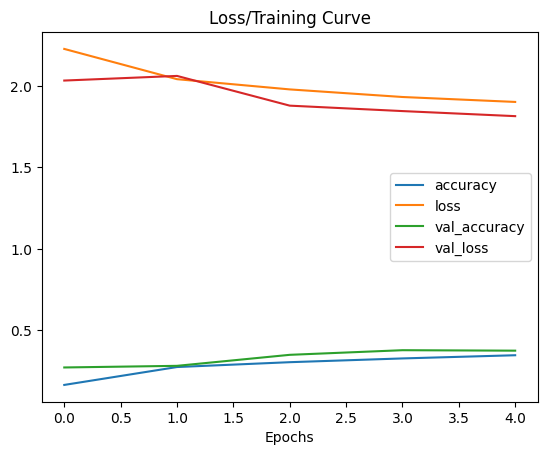

In [ ]:
model_metrics.plot(title="Loss/Training Curve", xlabel="Epochs");

In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
    """
    Reads an image from filename, turns it into a tensor and reshapes it
     to (img_shape, img_shape, colour_channels)
    """

    # Read in the image
    img = tf.io.read_file(filename)
    # Decode the read file into a tensor
    img = tf.image.decode_image(img)
    # Resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    # Rescale the image (get all values between 0 & 1)
    img = img/255.
    return img

In [ ]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model, filename, class_names=class_names):
    """
    Imports an image located at filename, makes a prediction with model
    and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    img = load_and_prep_image(filename)

    # Make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))

    # Add in logic for multi-class & get pred_class name
    if len(pred[0]) > 1:
      pred_class = class_names[tf.argmax(pred[0])]

    # Plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

## Making Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step


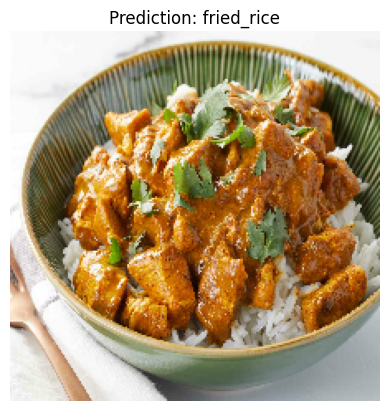

In [ ]:
pred_and_plot(computer_vision_cnn_model, "chicken.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


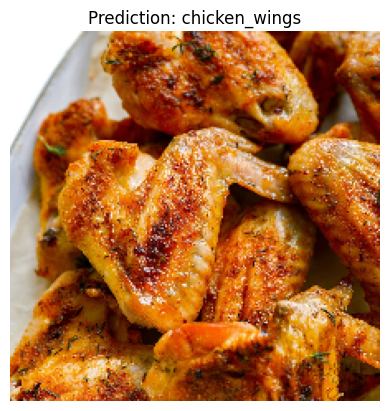

In [ ]:
pred_and_plot(computer_vision_cnn_model, "chicken_wings.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


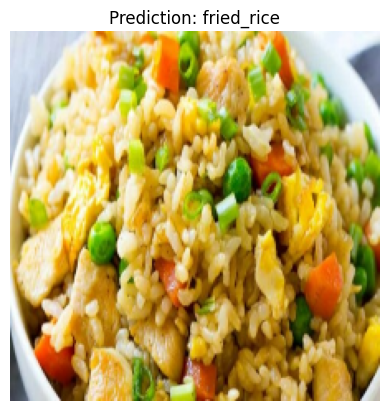

In [ ]:
pred_and_plot(computer_vision_cnn_model, "fried-rice.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


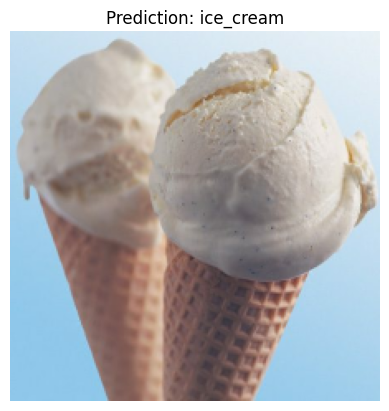

In [ ]:
pred_and_plot(computer_vision_cnn_model, "ice_cream.jpg")